In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

In [ ]:
c1 = np.loadtxt('c_1_5_1.5707963267948966.txt')
c2 = np.loadtxt('c_2_5_1.5707963267948966.txt')
# cδ1 = np.loadtxt('c_δ.txt')
# cδ2 = np.loadtxt('c_δ2.txt')

 
plt.plot((c1[:, 0] ), label='c_1')
plt.plot((c2[:, 0] ), label='c_2')
plt.xlim(0, 500)


7500
[ 9.67010386e-05  4.97364486e-04  2.16788198e-04 ...  5.00470923e-04
 -3.75235392e-04  1.96975654e-04]
-87.58780853174436
-0.27531167174460275
phase shift (rad): 3.1416  (≈ 1.000000⋅π)


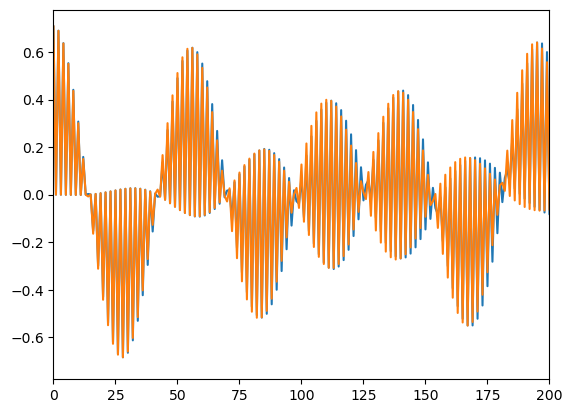

In [78]:
c1 = np.loadtxt('c_1_0_0.txt')
c2 = np.loadtxt('c_2_0_0.txt')
plt.plot((c1[:, 0] ), label='c_1')
plt.plot((c2[:, 0] ), label='c_2')
plt.xlim(0, 200)
A = c1[:,0]
B = c2[:,0]
nskip =1
dtN = 25
dtE = dtN/25
nsamples = A.size
print(nsamples)
# regularize datasets by subtracting mean and dividing by s.d.
A -= A.mean(); A /= A.std()
B -= B.mean(); B /= B.std()
# Find cross-correlation
xcorr = correlate(A, B)
print(xcorr/nsamples)
# delta time array to match xcorr
dt = np.arange(1-nsamples, nsamples)* nskip * dtE/41.34137
recovered_time_shift = dt[xcorr.argmax()]
print(recovered_time_shift)
i0 = np.argmax(np.abs(xcorr))
ϕ_peak = np.angle(xcorr[i0]/nsamples)
print(xcorr[i0]/nsamples)
print(f"phase shift (rad): {ϕ_peak:.4f}  (≈ {ϕ_peak/np.pi:.6f}⋅π)")

(0.0, 500.0)

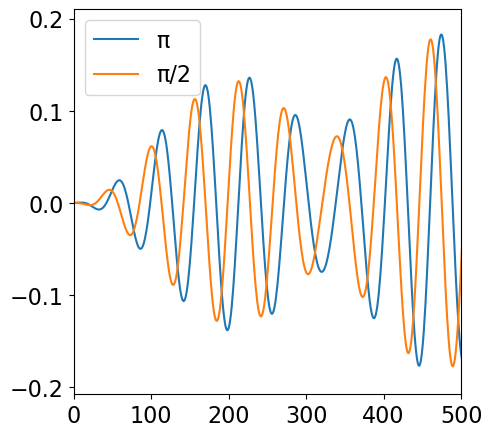

In [112]:
c1 = np.loadtxt('c_δ2_5_3.141592653589793.txt')
c2 = np.loadtxt('c_δ2_5_1.5707963267948966_0.0.txt')
plt.figure(figsize=(5,5))
plt.plot(c1[:, 0], label='π')
plt.plot(c2[:, 0], label='π/2')
plt.legend()
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'sans-serif'})
plt.xlim(0, 500)

Phase difference (rad): 0.0


(0.0, 500.0)

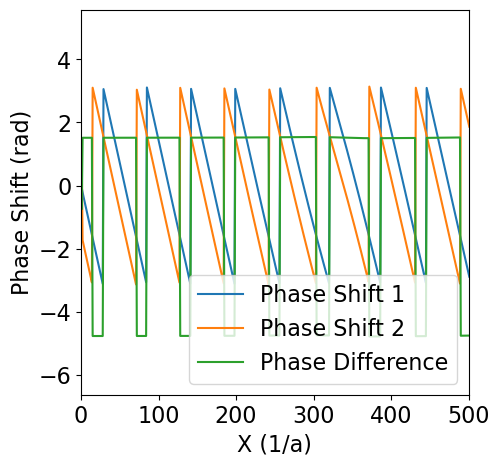

In [117]:
c1 = np.loadtxt('c_δ2_5_3.141592653589793.txt')
c2 = np.loadtxt('c_δ2_5_1.5707963267948966_0.0.txt')
phi = np.angle(c1[:, 0] + 1j*c1[:, 1])
phi2 = np.angle(c2[:, 0] + 1j*c2[:, 1])
print(f"Phase difference (rad):", phi2[0] - phi[0])
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'sans-serif'})
plt.figure(figsize=(5,5))
plt.plot(phi, label='Phase Shift 1')
plt.plot(phi2, label='Phase Shift 2')
plt.plot(phi - phi2, label='Phase Difference')
plt.legend()
plt.xlabel('X (1/a)')
plt.ylabel('Phase Shift (rad)')
plt.xlim(0, 500)

(7500, 2) (7500, 2)
Phase shift (rad): 2.8793  (≈ 0.916508⋅π)
Minimum sum of differences: 5.525842672629226 at roll index 28


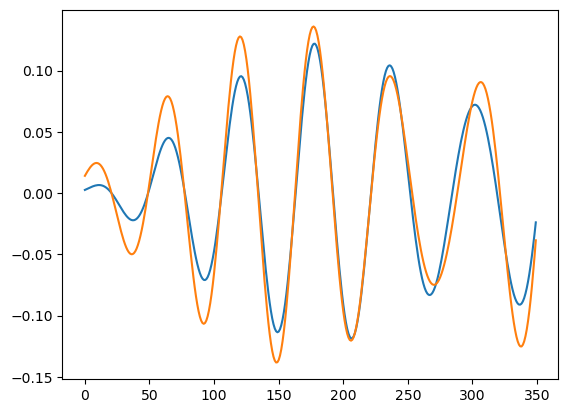

In [100]:
c1 = np.loadtxt('c_δ1_5_3.141592653589793.txt')
c2 = np.loadtxt('c_δ2_5_3.141592653589793.txt')
print(c1.shape, c2.shape)
start = 50
end = 400
minS = 10000
minI = 0
for i in range(50):
    d1 = np.roll(c1[:, 0], i)
    diff = np.abs(d1[start:end] - c2[start:end,0])
    s= np.sum(diff)
    plt.scatter(i,s, label=f'roll {i}')
    if s < minS:
        minS = s
        minI = i
dt = 1
ω = 2.79820/27.2114
τ =minI * dt
θ = ω * τ
print(f"Phase shift (rad): {θ:.4f}  (≈ {θ/np.pi:.6f}⋅π)")
print(f"Minimum sum of differences: {minS} at roll index {minI}")
plt.close()
c1= np.roll(c1[:, 0], minI)
plt.plot(c1[start:end], label='rolled c_1')
plt.plot(c2[start:end, 0], label='c_2')

In [ ]:
c1 = np.loadtxt('c_1_5_1.5707963267948966_0.0.txt')
c2 = np.loadtxt('c_δ2_5_3.141592653589793.txt')
A = c1[:,0] #+ 1j*c1[:,1]
B = c2[:,0] #+ 1j*c2[:,1]
nskip =1
dtN = 25
dtE = dtN/25
nsamples = A.size
# print(nsamples)
# regularize datasets by subtracting mean and dividing by s.d.
A -= A.mean(); A /= A.std()
B -= B.mean(); B /= B.std()
# Find cross-correlation
xcorr = correlate(A, B)
print(xcorr/nsamples)
# delta time array to match xcorr
dt = np.arange(1-nsamples, nsamples)* nskip * dtE/41.34137
recovered_time_shift = dt[xcorr.argmax()]
i0 = np.argmax(np.abs(xcorr))
print(recovered_time_shift)
ϕ_peak = np.angle(xcorr[i0])
# print(xcorr[iθ]/nsamples)
print(f"phase shift (rad): {ϕ_peak:.4f}  (≈ {ϕ_peak/np.pi:.2f}⋅π)")

[ 1.10516652e-04  1.19639021e-04  2.35315826e-04 ... -2.40710797e-08
 -2.51964513e-08 -2.46873002e-08]
35.04963671982811
phase shift (rad): 0.0000  (≈ 0.00⋅π)


Processing files: c_δ1_5_0.0_0.0.txt and c_δ2_5_0.0_0.0.txt
Input angle: 0.0 rad, Recovered phase shift: 3.1416 rad
Processing files: c_δ1_5_1.5707963267948966_0.0.txt and c_δ2_5_1.5707963267948966_0.0.txt
Input angle: 1.5707963267948966 rad, Recovered phase shift: 0.0000 rad
Processing files: c_δ1_5_3.141592653589793.txt and c_δ2_5_3.141592653589793.txt
Input angle: 3.141592653589793 rad, Recovered phase shift: 3.1416 rad
Recovered phase shifts (in π): [3.141592653589793, 0.0, 3.141592653589793]


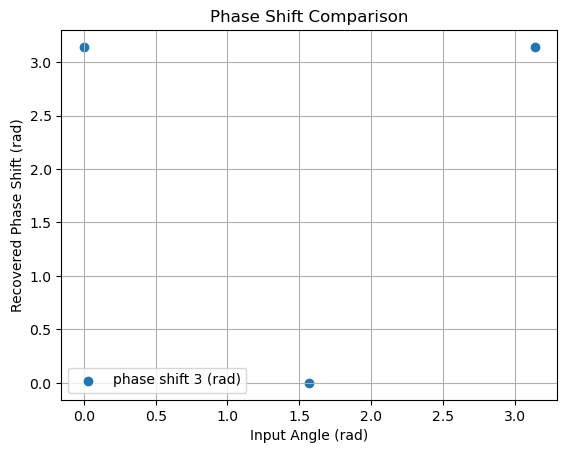

In [ ]:
def phase_shift(file_name1, file_name2):
    c1 = np.loadtxt(file_name1)
    c2 = np.loadtxt(file_name2)
    A = c1[:,0]
    B = c2[:,0]
    nskip =1
    dtN = 25
    dtE = dtN/25
    nsamples = A.size
    # print(nsamples)
    # regularize datasets by subtracting mean and dividing by s.d.
    A -= A.mean(); A /= A.std()
    B -= B.mean(); B /= B.std()
    # Find cross-correlation
    xcorr = correlate(A, B)
    # print(xcorr/nsamples)
    # delta time array to match xcorr
    dt = np.arange(1-nsamples, nsamples)* nskip * dtE/41.34137
    recovered_time_shift = dt[xcorr.argmax()]
    i0 = np.argmax(np.abs(xcorr))
    # print(recovered_time_shift)
    ϕ_peak = np.angle(xcorr[i0])
    # print(xcorr[i0]/nsamples)
    # print(f"phase shift (rad): {ϕ_peak:.4f}  (≈ {ϕ_peak/np.pi:.2f}⋅π)")
    return ϕ_peak
input_files_np_1 = ['c_1_5_0.0_0.0.txt','c_1_5_1.5707963267948966_0.0.txt','c_1_5_3.141592653589793.txt']
input_files_np_2 = ['c_2_5_0.0_0.0.txt','c_2_5_1.5707963267948966_0.0.txt','c_2_5_3.141592653589793.txt']
output_files_np_1 =['c_δ1_5_0.0_0.0.txt','c_δ1_5_1.5707963267948966_0.0.txt','c_δ1_5_3.141592653589793.txt']
output_files_np_2 =['c_δ2_5_0.0_0.0.txt','c_δ2_5_1.5707963267948966_0.0.txt','c_δ2_5_3.141592653589793.txt']
input_angles = [0.0, 1.5707963267948966, 3.141592653589793]
y = []
for i in range(len(input_files_np_1)):
    print(f"Processing files: {output_files_np_1[i]} and {output_files_np_2[i]}")
    y.append(phase_shift(input_files_np_1[i], input_files_np_2[i]))
    print(f"Input angle: {input_angles[i]} rad, Recovered phase shift: {y[i]:.4f} rad")
######
print("Recovered phase shifts (in π):", y)
plt.scatter(input_angles, y, label=f'phase shift {i+1} (rad)')
plt.legend()
plt.title('Phase Shift Comparison')
plt.xlabel('Input Angle (rad)')
plt.ylabel('Recovered Phase Shift (rad)')
plt.grid()
plt.show()

In [ ]:
import numpy as np
from scipy.signal import hilbert

def phase_shift_fft_full(file1, file2, dt_au=1.0):
    # 1) load & normalize
    A = np.loadtxt(file1)[:,0]
    B = np.loadtxt(file2)[:,0]
    A = (A - A.mean())/A.std()
    B = (B - B.mean())/B.std()

    # 2) build analytic (complex) signals
    hA = hilbert(A)
    hB = hilbert(B)

    # 3) full FFT (keep complex)
    N  = len(hA)
    FA = np.fft.fft(hA)           # <— use fft, not rfft
    FB = np.fft.fft(hB)

    # 4) cross‑spectrum
    S  = FA * np.conj(FB)        # complex array length N

    # 5) frequency axis (in a.u.^-1)
    freqs = np.fft.fftfreq(N, d=dt_au)

    # 6) pick the bin with max magnitude
    idx = np.argmax(np.abs(S))

    # 7) extract phase and frequency
    phi = np.angle(S[idx])       # your true Δφ in radians
    f0  = freqs[idx]             # carrier frequency in a.u.^-1

    return phi, f0

# — example usage —
nskip = 1
dtN   = 25
dtE   = dtN/25               # =1 a.u. per sample
dt_au = nskip * dtE

φ, f0 = phase_shift_fft_full(
    'c_1_5_3.141592653589793.txt',
    'c_2_5_3.141592653589793.txt',
    dt_au
)

print(f"Recovered phase shift: {φ:.4f} rad")
print(f"Carrier freq: {f0:.4f} a.u.^-1")


True Δt      = 0.033333 s  → injected φ = 1.047 rad (60.0°)
Found lag    = 33 samples → Δt_est = 0.033000 s
Recovered φ  = 1.037 rad (59.4°)


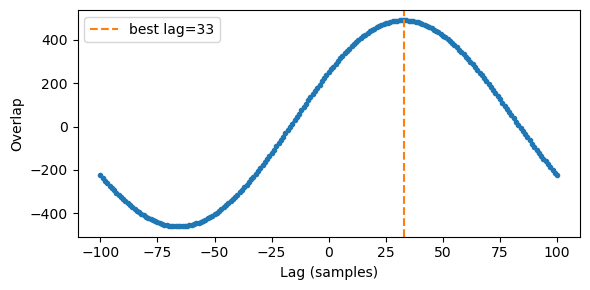

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Parameters
fs    = 1000        # sampling rate [Hz]
T     = 1.0         # total time [s]
f0    = 5           # signal frequency [Hz]
phi0  = np.pi/3     # injected phase shift [rad]

# 2) Build time axis & signals
t  = np.arange(0, T, 1/fs)
# reference
x1 = np.sin(2*np.pi*f0*t)
# phase‑shifted by phi0 → equivalent time shift Δt_true
Δt_true = phi0 / (2*np.pi*f0)
x2 = np.sin(2*np.pi*f0*(t - Δt_true))

# 3) Compute overlap vs integer lag
max_lag = int(0.1*fs)        # search ±0.1 s around zero
lags    = np.arange(-max_lag, max_lag+1)
corr    = np.empty_like(lags, dtype=float)

for i, L in enumerate(lags):
    if L < 0:
        corr[i] = np.dot(x1[-L:], x2[: len(x1)+L])
    else:
        corr[i] = np.dot(x1[:len(x1)-L], x2[L:])

# 4) Pick the best lag
best_idx    = np.argmax(corr)
lag_samples = lags[best_idx]
Δt_est      = lag_samples / fs    # estimated time delay [s]

# 5) Convert to phase
#    in radians:   φ = 2π f0 Δt
phi_est_rad = 2*np.pi * f0 * Δt_est
#    in degrees:  φ° = 360° f0 Δt
phi_est_deg = 360.0 * f0 * Δt_est

# 6) Report
print(f"True Δt      = {Δt_true:.6f} s  → injected φ = {phi0:.3f} rad ({phi0*180/np.pi:.1f}°)")
print(f"Found lag    = {lag_samples} samples → Δt_est = {Δt_est:.6f} s")
print(f"Recovered φ  = {phi_est_rad:.3f} rad ({phi_est_deg:.1f}°)")

# 7) Visualize
plt.figure(figsize=(6,3))
plt.plot(lags, corr, '-o', ms=3)
plt.axvline(lag_samples, color='C1', ls='--', label=f'best lag={lag_samples}')
plt.xlabel('Lag (samples)')
plt.ylabel('Overlap')
plt.legend()
plt.tight_layout()
plt.show()


Injected φ = 0.000 rad
  → Est. carrier f = 6.945e+14 Hz
  → Δt = 46.539 fs
  → Recovered φ = 203.093 rad (11636.4°)

Injected φ = 1.571 rad
  → Est. carrier f = 6.945e+14 Hz
  → Δt = 46.201 fs
  → Recovered φ = 201.615 rad (11551.7°)

Injected φ = 3.142 rad
  → Est. carrier f = 6.504e+14 Hz
  → Δt = 45.838 fs
  → Recovered φ = 187.331 rad (10733.3°)



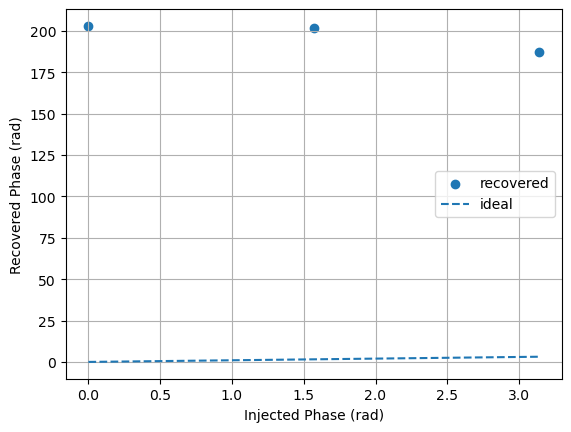

In [76]:
import numpy as np
from scipy.signal import correlate
import matplotlib.pyplot as plt

def phase_shift(file1: str, file2: str):
    # --- 1) load & normalize ---
    c1 = np.loadtxt(file1)
    c2 = np.loadtxt(file2)
    A, B = c1[:,0], c2[:,0]
    A = (A - A.mean()) / A.std()
    B = (B - B.mean()) / B.std()

    # --- 2) estimate carrier frequency via FFT on A ---
    N     = len(A)
    # time step in atomic units and seconds
    nskip = 1
    dtN   = 25
    dtE   = dtN/25             # =1 a.u. per sample
    au2s  = 2.418884e-17        # 1 a.u. = 2.418884e-17 s
    dt_s  = nskip * dtE * au2s # seconds per sample
    fs    = 1.0 / dt_s         # sampling rate [Hz]

    # real → one‐sided spectrum
    FA    = np.fft.rfft(A)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    peak  = np.argmax(np.abs(FA))
    f_est = freqs[peak]        # estimated carrier [Hz]

    # --- 3) real cross‐correlation to get Δt ---
    xcorr = correlate(A, B, mode='full')
    # build lag vector in fs
    dt_fs_vec = np.arange(1-N, N) * (nskip * dtE / 41.34137)
    i0        = np.argmax(xcorr)
    Δt_fs     = dt_fs_vec[i0]             # time shift [fs]
    Δt_s      = Δt_fs * 1e-15             # time shift [s]

    # --- 4) compute phase shift from Δt_s & f_est ---
    phi_rad = 2*np.pi * f_est * Δt_s       # in radians
    phi_deg = phi_rad * 180/np.pi          # in degrees

    return Δt_fs, f_est, phi_rad, phi_deg

# ——— Example usage ———
files1 = [
    'c_δ1_5_0.0_0.0.txt',
    'c_δ1_5_1.5707963267948966_0.0.txt',
    'c_δ1_5_3.141592653589793.txt'
]
files2 = [
    'c_δ2_5_0.0_0.0.txt',
    'c_δ2_5_1.5707963267948966_0.0.txt',
    'c_δ2_5_3.141592653589793.txt'
]
in_angles = [0.0, np.pi/2, np.pi]

recovered = []
for f1, f2, φ_in in zip(files1, files2, in_angles):
    Δt_fs, f_est, φ_out, φ_out_deg = phase_shift(f1, f2)
    recovered.append(φ_out)
    print(f"Injected φ = {φ_in:.3f} rad")
    print(f"  → Est. carrier f = {f_est:.3e} Hz")
    print(f"  → Δt = {Δt_fs:.3f} fs")
    print(f"  → Recovered φ = {φ_out:.3f} rad ({φ_out_deg:.1f}°)\n")

# ——— Plot recovered vs ideal ———
plt.scatter(in_angles, recovered, label='recovered')
plt.plot(in_angles, in_angles, '--', label='ideal')
plt.xlabel('Injected Phase (rad)')
plt.ylabel('Recovered Phase (rad)')
plt.legend()
plt.grid()
plt.show()
